# 02: Causal Graphs, DAGs, and Assumptions

We focus on the part of causal inference that happens before estimation: writing down assumptions as a graph. DoWhy is most useful when the analyst treats the graph as the causal design, not as a decoration.

We will build a example dataset with several important graph roles: confounders, a treatment, a mediator, an outcome, an instrument-like assignment variable, and a collider. Then we will show how different graph assumptions lead to different adjustment logic and different estimates.


## Learning Goals

By the end, you should be able to:

- Explain what a directed acyclic graph, or DAG, represents.
- Distinguish confounders, mediators, colliders, instruments, treatments, and outcomes.
- Explain why a graph should be written before selecting an estimator.
- Use NetworkX to check and visualize a graph.
- Use DoWhy to compare how graph assumptions affect common causes, instruments, estimands, and estimates.
- Avoid the beginner mistake of adjusting for every available variable.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use mostly simulated or semi-synthetic observational datasets to study **Causal Graphs, DAGs, And Assumptions**. DoWhy is mainly about causal modeling discipline: graph, estimand, estimator, and refuter. A controlled dataset lets us show how a change in assumptions changes the estimand and the credibility of the estimate.

Read each row as an observed unit in a business or policy system. The treatment, outcome, common causes, instruments, mediators, and anomaly indicators are named to mirror applied causal workflows and keep the examples close to realistic analysis language. The experiment treats graph structure as the object of study. The data are useful because the graph is known before any estimator or discovery algorithm is run. The examples are designed to make assumptions visible. Pay attention to timing, common causes, mediators, colliders, and variables that should not be adjusted for.

The simulation is designed to make the identifying assumptions and diagnostic checks visible. It is meant to expose the assumptions that would be hidden in real data, where the true counterfactual outcome is unavailable.


## Mathematical Foundation

<!-- math-foundation-note -->

A causal DAG encodes assumptions about how interventions change distributions. The backdoor adjustment formula is

$$
\mathbb{E}\{Y\mid do(D=d)\}=\sum_x \mathbb{E}(Y\mid D=d,X=x)\Pr(X=x).
$$

This formula is valid when $X$ blocks all backdoor paths from $D$ to $Y$ and contains no inappropriate post-treatment variables.


## Why Graphs Come Before Estimators

A causal graph is a compact statement of assumptions about how variables cause each other. The graph answers questions like:

- Which variables happen before treatment?
- Which variables affect treatment assignment?
- Which variables affect the outcome?
- Which variables are downstream consequences of treatment?
- Which variables should be adjusted for, and which should not?

The estimator comes later. A regression, matching estimator, or weighting estimator cannot decide by itself whether a variable is a confounder, mediator, or collider. That decision comes from the causal graph and domain knowledge.





## Tutorial Workflow

#### Setup

This setup mirrors the earlier DoWhy tutorial lessons. It imports the causal, data, and plotting libraries, sets output folders, fixes the random seed, and suppresses known third-party deprecation warnings so the lesson stays readable for students.


In [ ]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import platform
import sys
import warnings
START_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in [START_DIR, *START_DIR.parents] if (candidate / "pyproject.toml").exists()),
    START_DIR,
)
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "dowhy"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = PROJECT_ROOT / ".cache" / "matplotlib"
for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR))
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="seaborn.categorical")
warnings.filterwarnings("ignore", module="pydot.dot_parser")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
# Compatibility shim for DoWhy estimators written against older pandas Series integer indexing.
if not getattr(pd.Series, "_dowhy_integer_position_patch", False):
    _original_series_getitem = pd.Series.__getitem__
    def _dowhy_series_getitem_compat(self, key):
        try:
            return _original_series_getitem(self, key)
        except KeyError:
            if isinstance(key, int) and key not in self.index:
                return self.iloc[key]
            raise
    pd.Series.__getitem__ = _dowhy_series_getitem_compat
    pd.Series._dowhy_integer_position_patch = True
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
# Compatibility shim for DoWhy versions that expect the older NetworkX d_separated API.
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator
import statsmodels.formula.api as smf
import dowhy
from dowhy import CausalModel
RANDOM_SEED = 11
rng = np.random.default_rng(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")
print(f"DoWhy version: {getattr(dowhy, '__version__', 'unknown')}")
print(f"Notebook directory: {NOTEBOOK_DIR}")


The lesson is ready if this step prints a DoWhy version.


### Graph Vocabulary

Before writing code, we need vocabulary. The same column can play different causal roles in different questions, so it is better to define roles relative to a specific treatment and outcome.

This table gives practical definitions used throughout the lesson.


| term | shape | plain_language_definition | adjustment_guidance |
| --- | --- | --- | --- |
| Treatment | A | The variable whose causal effect we want to estimate. | Never adjust away the treatment itself when estimating its effect. |
| Outcome | Y | The variable we expect the treatment to change. | The outcome is modeled, not adjusted for as a control. |
| Confounder | C -> A and C -> Y | A pre-treatment common cause of treatment and outcome. | Usually adjust for observed confounders to block backdoor paths. |
| Mediator | A -> M -> Y | A post-treatment pathway variable through which part of the effect flows. | Do not adjust for mediators when estimating the total effect. |
| Collider | A -> K <- Y | A variable caused by two other variables on a path. | Do not condition on colliders unless the estimand specifically requires it. |
| Instrument | Z -> A -> Y | A variable that shifts treatment but does not directly affect the outcome except through treatment. | Useful for IV designs; not the same as a confounder. |


The most important lesson is that not every predictive variable should become a control. A good predictive model may use mediators and colliders; a causal adjustment set for a total effect usually should not.


### Teaching Scenario

We will use a product-style scenario with the following causal question:

> What is the total effect of `feature_exposure` on next-week `weekly_value`?

The word **total** matters. It means we want the effect through all causal pathways, including the pathway where exposure improves `satisfaction_depth`, which then improves `weekly_value`.


#### Create Data with Multiple Graph Roles

The code below simulates data from a known causal system. The true total effect is known because we choose the data-generating equations.

The key roles are:

- `user_engagement`, `prior_activity`, and `account_age_weeks` are confounders.
- `feature_exposure` is the treatment.
- `satisfaction_depth` is a mediator.
- `weekly_value` is the outcome.
- `rollout_batch` is an instrument-like assignment shifter.
- `support_ticket` is a collider caused by treatment and outcome.


In [2]:
# Define reusable helpers for the Create Data With Multiple Graph Roles section.
def make_graph_teaching_data(n=5_000, seed=11):
    """
    Idea: Construct the graph example data used in the Create Data With Multiple Graph Roles section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n : int
        Number of observations or repetitions to generate.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing data, truth.
    """
    local_rng = np.random.default_rng(seed)
    user_engagement = local_rng.normal(loc=0.0, scale=1.0, size=n)
    prior_activity = np.clip(
        local_rng.poisson(lam=np.exp(1.0 + 0.25 * user_engagement), size=n),
        0,
        25,
    )
    account_age_weeks = local_rng.gamma(shape=2.0, scale=3.0, size=n)
    rollout_batch = local_rng.binomial(n=1, p=0.50, size=n)
    treatment_logit = (
        -0.70
        + 0.85 * user_engagement
        + 0.040 * prior_activity
        + 0.025 * account_age_weeks
        + 1.05 * rollout_batch
    )
    treatment_probability = 1 / (1 + np.exp(-treatment_logit))
    feature_exposure = local_rng.binomial(n=1, p=treatment_probability, size=n)
    exposure_to_mediator = 0.45
    mediator_to_outcome = 1.55
    direct_effect = 1.15
    true_total_effect = direct_effect + exposure_to_mediator * mediator_to_outcome
    satisfaction_depth = (
        exposure_to_mediator * feature_exposure
        + 0.55 * user_engagement
        + 0.025 * prior_activity
        + 0.020 * account_age_weeks
        + local_rng.normal(loc=0.0, scale=0.70, size=n)
    )
    weekly_value = (
        3.0
        + direct_effect * feature_exposure
        + mediator_to_outcome * satisfaction_depth
        + 1.05 * user_engagement
        + 0.055 * prior_activity
        + 0.025 * account_age_weeks
        + local_rng.normal(loc=0.0, scale=1.0, size=n)
    )
    support_ticket_logit = -0.50 + 4.00 * feature_exposure - 0.80 * weekly_value + local_rng.normal(
        loc=0.0,
        scale=0.25,
        size=n,
    )
    support_ticket = local_rng.binomial(n=1, p=1 / (1 + np.exp(-support_ticket_logit)), size=n)
    data = pd.DataFrame(
        {
            "feature_exposure": feature_exposure,
            "satisfaction_depth": satisfaction_depth,
            "weekly_value": weekly_value,
            "user_engagement": user_engagement,
            "prior_activity": prior_activity,
            "account_age_weeks": account_age_weeks,
            "rollout_batch": rollout_batch,
            "support_ticket": support_ticket,
            "treatment_probability": treatment_probability,
        }
    )
    truth = {
        "direct_effect": direct_effect,
        "exposure_to_mediator": exposure_to_mediator,
        "mediator_to_outcome": mediator_to_outcome,
        "true_total_effect": true_total_effect,
    }
    return data, truth
graph_df, truth = make_graph_teaching_data()
print(f"Rows: {len(graph_df):,}")
print(f"Known direct effect: {truth['direct_effect']:.4f}")
print(f"Known mediated component: {truth['exposure_to_mediator'] * truth['mediator_to_outcome']:.4f}")
print(f"Known total effect: {truth['true_total_effect']:.4f}")
graph_df.head()


Rows: 5,000
Known direct effect: 1.1500
Known mediated component: 0.6975
Known total effect: 1.8475


,feature_exposure,satisfaction_depth,weekly_value,user_engagement,prior_activity,account_age_weeks,rollout_batch,support_ticket,treatment_probability
0,0,-0.609834,1.956259,0.034193,6,13.404290,0,0,0.476061
1,1,1.402446,8.731601,1.359748,5,9.848849,0,0,0.711362
2,1,0.697735,7.479900,1.224721,5,7.062851,1,0,0.854157
3,1,1.676406,4.837179,-0.510307,2,5.280177,1,1,0.532017
4,0,0.650327,2.546708,-0.297970,3,4.342803,0,0,0.326358


The data contain both pre-treatment variables and post-treatment variables. That mixture is realistic and dangerous: if we adjust for everything in the table, we will usually answer the wrong causal question.


#### Data Dictionary for the Graph Dataset

This table documents the role and timing of each column. In real work, this table should be built before modeling because timing mistakes are one of the most common sources of causal errors.


| column | graph_role | timing | use_in_total_effect_adjustment |
| --- | --- | --- | --- |
| feature_exposure | treatment | treatment time | treatment, not a control |
| weekly_value | outcome | post-treatment outcome window | outcome, not a control |
| user_engagement | confounder | pre-treatment | adjust |
| prior_activity | confounder | pre-treatment | adjust |
| account_age_weeks | confounder | pre-treatment | adjust |
| rollout_batch | instrument-like assignment shifter | pre-treatment assignment driver | not needed for backdoor adjustment, useful to know |
| satisfaction_depth | mediator | post-treatment, before outcome | do not adjust for total effect |
| support_ticket | collider | post-treatment diagnostic event | do not adjust |
| treatment_probability | simulation diagnostic | known only because data are simulated | do not use as an observed production column |


The adjustment column is the practical takeaway. For the total effect, use pre-treatment common causes. Do not control for the mediator or the collider.


### Basic Checks and Role Sanity

The summary below checks treatment prevalence, outcome scale, mediator scale, support-ticket frequency, and the assignment probability range.


In [3]:
summary = graph_df.agg(
    {
        "feature_exposure": ["mean", "sum"],
        "weekly_value": ["mean", "std", "min", "max"],
        "satisfaction_depth": ["mean", "std", "min", "max"],
        "user_engagement": ["mean", "std", "min", "max"],
        "prior_activity": ["mean", "std", "min", "max"],
        "account_age_weeks": ["mean", "std", "min", "max"],
        "rollout_batch": ["mean", "sum"],
        "support_ticket": ["mean", "sum"],
        "treatment_probability": ["mean", "std", "min", "max"],
    }
).T
summary.to_csv(TABLE_DIR / "02_graph_dataset_summary.csv")
summary


,mean,sum,std,min,max
feature_exposure,0.527800,2639.0,NaN,NaN,NaN
weekly_value,4.588921,NaN,2.861108,-6.672703,14.176098
satisfaction_depth,0.428490,NaN,0.973872,-2.612379,3.742802
user_engagement,0.008163,NaN,0.999482,-3.281576,3.731561
prior_activity,2.768600,NaN,1.799473,0.000000,11.000000
account_age_weeks,5.934185,NaN,4.232782,0.016651,36.768703
rollout_batch,0.504600,2523.0,NaN,NaN,NaN
support_ticket,0.218800,1094.0,NaN,NaN,NaN
treatment_probability,0.519501,NaN,0.214182,0.033089,0.977275


The treatment is common enough to compare exposed and unexposed users, and the support-ticket collider is present but not universal. Those properties make the examples easier to see.


#### Show That Treatment Assignment is Confounded

This plot shows why a graph is needed. Treatment is related to baseline engagement and to the instrument-like rollout variable. Only the baseline variables are common causes of treatment and outcome; rollout shifts assignment but does not directly cause the outcome in the data-generating process.


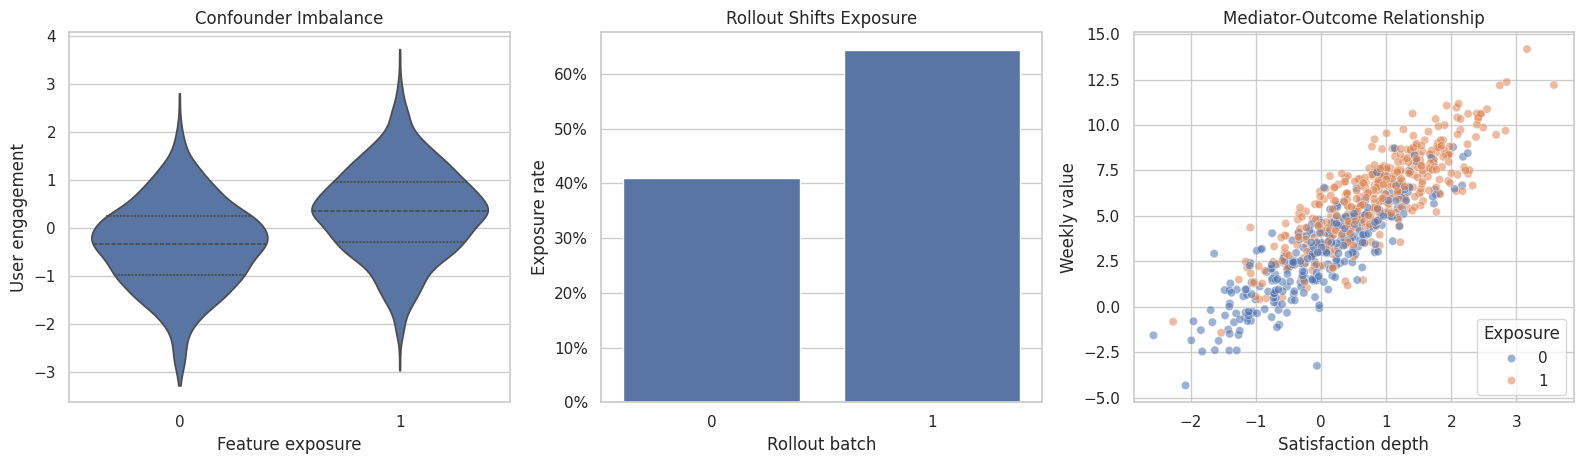

In [4]:
# Build and label the diagnostic visualization for the Show That Treatment Assignment Is Confounded section.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sns.violinplot(
    data=graph_df,
    x="feature_exposure",
    y="user_engagement",
    inner="quartile",
    cut=0,
    ax=axes[0],
)
axes[0].set_title("Confounder Imbalance")
axes[0].set_xlabel("Feature exposure")
axes[0].set_ylabel("User engagement")
sns.barplot(
    data=graph_df,
    x="rollout_batch",
    y="feature_exposure",
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("Rollout Shifts Exposure")
axes[1].set_xlabel("Rollout batch")
axes[1].set_ylabel("Exposure rate")
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
sns.scatterplot(
    data=graph_df.sample(700, random_state=RANDOM_SEED),
    x="satisfaction_depth",
    y="weekly_value",
    hue="feature_exposure",
    alpha=0.55,
    ax=axes[2],
)
axes[2].set_title("Mediator-Outcome Relationship")
axes[2].set_xlabel("Satisfaction depth")
axes[2].set_ylabel("Weekly value")
axes[2].legend(title="Exposure", loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_graph_role_sanity_checks.png", dpi=160, bbox_inches="tight")
plt.show()


The left panel shows confounding, the middle panel shows assignment variation from rollout, and the right panel shows why the mediator is tempting to control for. The graph tells us which temptation is appropriate for the causal question.


#### Define the Main DAG

This edge list encodes the data-generating graph. It includes direct and mediated treatment effects, observed confounding, an instrument-like rollout shifter, and a collider.


In [5]:
main_edges = [
    ("user_engagement", "feature_exposure"),
    ("user_engagement", "satisfaction_depth"),
    ("user_engagement", "weekly_value"),
    ("prior_activity", "feature_exposure"),
    ("prior_activity", "satisfaction_depth"),
    ("prior_activity", "weekly_value"),
    ("account_age_weeks", "feature_exposure"),
    ("account_age_weeks", "satisfaction_depth"),
    ("account_age_weeks", "weekly_value"),
    ("rollout_batch", "feature_exposure"),
    ("feature_exposure", "satisfaction_depth"),
    ("satisfaction_depth", "weekly_value"),
    ("feature_exposure", "weekly_value"),
    ("feature_exposure", "support_ticket"),
    ("weekly_value", "support_ticket"),
]
G = nx.DiGraph(main_edges)
graph_checks = pd.DataFrame(
    [
        {"check": "is_directed", "value": nx.is_directed(G)},
        {"check": "is_acyclic", "value": nx.is_directed_acyclic_graph(G)},
        {"check": "node_count", "value": G.number_of_nodes()},
        {"check": "edge_count", "value": G.number_of_edges()},
    ]
)
graph_checks.to_csv(TABLE_DIR / "02_main_graph_checks.csv", index=False)
graph_checks


,check,value
0,is_directed,True
1,is_acyclic,True
2,node_count,8
3,edge_count,15


A causal DAG must be acyclic. Arrows point forward in the graph without looping back. If a graph has a cycle, it may describe equilibrium or feedback behavior rather than a DAG in the usual DoWhy effect-identification workflow.



## Diagnostics and Interpretation

#### Visualize the Main DAG

The code below draws the main example graph with explicit arrows. The positions are chosen to communicate timing: baseline variables on the left, treatment in the middle, mediator and outcome on the right, and the collider below.


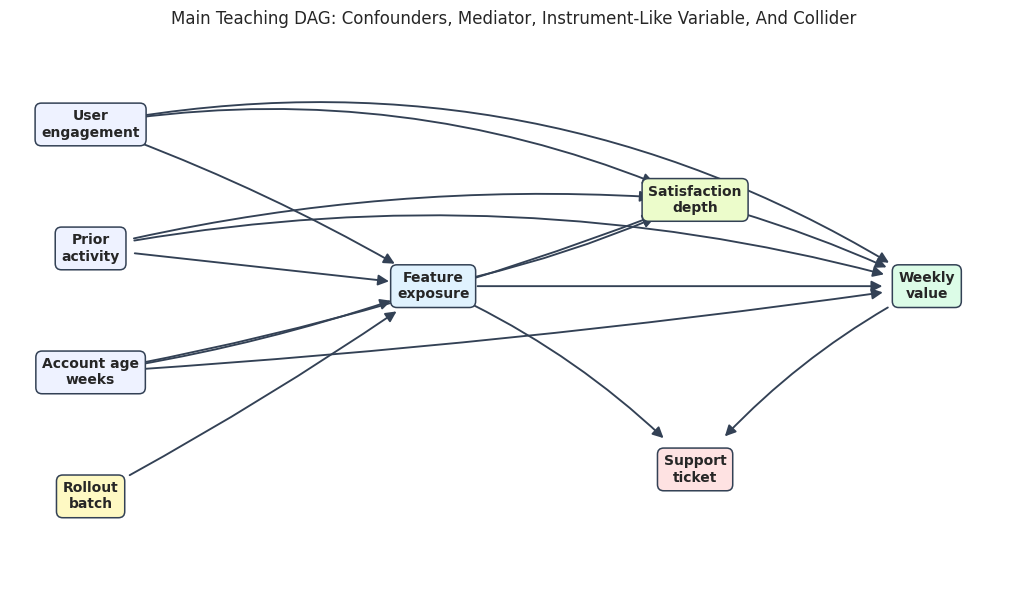

In [6]:
# Build and label the diagnostic visualization for the Visualize The Main DAG section.
node_positions = {
    "user_engagement": (0.08, 0.86),
    "prior_activity": (0.08, 0.63),
    "account_age_weeks": (0.08, 0.40),
    "rollout_batch": (0.08, 0.17),
    "feature_exposure": (0.42, 0.56),
    "satisfaction_depth": (0.68, 0.72),
    "weekly_value": (0.91, 0.56),
    "support_ticket": (0.68, 0.22),
}
node_labels = {
    "user_engagement": "User\nengagement",
    "prior_activity": "Prior\nactivity",
    "account_age_weeks": "Account age\nweeks",
    "rollout_batch": "Rollout\nbatch",
    "feature_exposure": "Feature\nexposure",
    "satisfaction_depth": "Satisfaction\ndepth",
    "weekly_value": "Weekly\nvalue",
    "support_ticket": "Support\nticket",
}
role_colors = {
    "user_engagement": "#eef2ff",
    "prior_activity": "#eef2ff",
    "account_age_weeks": "#eef2ff",
    "rollout_batch": "#fef9c3",
    "feature_exposure": "#e0f2fe",
    "satisfaction_depth": "#ecfccb",
    "weekly_value": "#dcfce7",
    "support_ticket": "#fee2e2",
}
edge_radii = {
    ("user_engagement", "feature_exposure"): -0.05,
    ("prior_activity", "feature_exposure"): 0.00,
    ("account_age_weeks", "feature_exposure"): 0.05,
    ("user_engagement", "satisfaction_depth"): -0.15,
    ("prior_activity", "satisfaction_depth"): -0.08,
    ("account_age_weeks", "satisfaction_depth"): 0.05,
    ("user_engagement", "weekly_value"): -0.20,
    ("prior_activity", "weekly_value"): -0.12,
    ("account_age_weeks", "weekly_value"): 0.02,
    ("rollout_batch", "feature_exposure"): 0.03,
    ("feature_exposure", "satisfaction_depth"): 0.06,
    ("satisfaction_depth", "weekly_value"): -0.05,
    ("feature_exposure", "weekly_value"): 0.00,
    ("feature_exposure", "support_ticket"): -0.10,
    ("weekly_value", "support_ticket"): 0.10,
}
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_axis_off()
for source, target in main_edges:
    ax.annotate(
        "",
        xy=node_positions[target],
        xytext=node_positions[source],
        arrowprops=dict(
            arrowstyle="-|>",
            color="#334155",
            linewidth=1.35,
            mutation_scale=16,
            shrinkA=32,
            shrinkB=32,
            connectionstyle=f"arc3,rad={edge_radii.get((source, target), 0.0)}",
        ),
        zorder=1,
    )
for node, (x, y) in node_positions.items():
    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor=role_colors[node],
            edgecolor="#334155",
            linewidth=1.1,
        ),
        zorder=2,
    )
ax.set_title("Main Teaching DAG: Confounders, Mediator, Instrument-Like Variable, And Collider", pad=18)
fig.savefig(FIGURE_DIR / "02_main_teaching_dag.png", dpi=160, bbox_inches="tight")
plt.show()


This picture is the causal design for the total-effect question. The mediator and collider are downstream of treatment, so controlling for them would change the question or introduce bias.


#### Inspect Graph Structure Programmatically

NetworkX can help audit graph structure. The code below checks parents, children, ancestors, and descendants for the treatment and outcome.


In [7]:
def sorted_nodes(nodes):
    """
    Idea: Compute the sorted nodes needed in the Inspect Graph Structure Programmatically section and return it in a form the next cells can inspect.
    
    Parameters
    ----------
    nodes : object
        Graph node information used for drawing or graph comparison.
    
    Returns
    -------
    str
        Comma-separated node list, or `none` when no nodes are available.
    """
    return ", ".join(sorted(nodes)) if nodes else "none"
structure_audit = pd.DataFrame(
    [
        {"relationship": "parents_of_treatment", "nodes": sorted_nodes(G.predecessors("feature_exposure"))},
        {"relationship": "children_of_treatment", "nodes": sorted_nodes(G.successors("feature_exposure"))},
        {"relationship": "ancestors_of_outcome", "nodes": sorted_nodes(nx.ancestors(G, "weekly_value"))},
        {"relationship": "descendants_of_treatment", "nodes": sorted_nodes(nx.descendants(G, "feature_exposure"))},
        {"relationship": "parents_of_collider", "nodes": sorted_nodes(G.predecessors("support_ticket"))},
    ]
)
structure_audit.to_csv(TABLE_DIR / "02_graph_structure_audit.csv", index=False)
structure_audit


,relationship,nodes
0,parents_of_treatment,"account_age_weeks, prior_activity, rollout_batch, user_engagement"
1,children_of_treatment,"satisfaction_depth, support_ticket, weekly_value"
2,ancestors_of_outcome,"account_age_weeks, feature_exposure, prior_activity, rollout_batch, satisfaction_depth, user_engagement"
3,descendants_of_treatment,"satisfaction_depth, support_ticket, weekly_value"
4,parents_of_collider,"feature_exposure, weekly_value"


The descendants of treatment include the mediator, the outcome, and the collider. That descendant status is exactly why blindly adjusting for every column would be dangerous for a total-effect question.


### Path-Level Reasoning

A DAG is useful because it lets us reason about paths. Some paths are causal paths we want to preserve; others are backdoor paths we want to block; collider paths should usually remain closed.


| path | path_type | for_total_effect | reason |
| --- | --- | --- | --- |
| feature_exposure -> weekly_value | direct causal path | keep open | This is part of the total effect. |
| feature_exposure -> satisfaction_depth -> weekly_value | mediated causal path | keep open | This is also part of the total effect. |
| feature_exposure <- user_engagement -> weekly_value | backdoor path | block by adjustment | Engagement drives both exposure and outcome. |
| feature_exposure <- prior_activity -> weekly_value | backdoor path | block by adjustment | Prior activity drives both exposure and outcome. |
| feature_exposure <- account_age_weeks -> weekly_value | backdoor path | block by adjustment | Account age drives both exposure and outcome. |
| feature_exposure <- rollout_batch | instrument-like assignment path | assignment source | Rollout shifts exposure and has no direct outcome arrow in this graph. |
| feature_exposure -> support_ticket <- weekly_value | collider path | leave closed | Conditioning on support_ticket can open a noncausal path. |


This table is the bridge between graph drawing and modeling. The adjustment set should block the backdoor paths without blocking the causal paths or opening the collider path.


### Manual Adjustment Sets

To make the graph logic concrete, we will estimate several ordinary regressions with different control sets. These are not all valid total-effect estimators; they are examples showing what happens when we adjust for the wrong variables.


In [8]:
# Fit or evaluate the model objects used in the Manual Adjustment Sets section.
adjustment_formulas = [
    {
        "specification": "naive_no_controls",
        "formula": "weekly_value ~ feature_exposure",
        "target_if_assumptions_were_valid": "association, not causal under confounding",
    },
    {
        "specification": "confounders_only",
        "formula": "weekly_value ~ feature_exposure + user_engagement + prior_activity + account_age_weeks",
        "target_if_assumptions_were_valid": "total effect",
    },
    {
        "specification": "confounders_plus_rollout",
        "formula": "weekly_value ~ feature_exposure + user_engagement + prior_activity + account_age_weeks + rollout_batch",
        "target_if_assumptions_were_valid": "total effect with unnecessary assignment shifter included",
    },
    {
        "specification": "confounders_plus_mediator",
        "formula": "weekly_value ~ feature_exposure + user_engagement + prior_activity + account_age_weeks + satisfaction_depth",
        "target_if_assumptions_were_valid": "direct-effect-like quantity, not total effect",
    },
    {
        "specification": "confounders_plus_collider",
        "formula": "weekly_value ~ feature_exposure + user_engagement + prior_activity + account_age_weeks + support_ticket",
        "target_if_assumptions_were_valid": "distorted by conditioning on a collider",
    },
    {
        "specification": "all_available_controls",
        "formula": "weekly_value ~ feature_exposure + user_engagement + prior_activity + account_age_weeks + rollout_batch + satisfaction_depth + support_ticket",
        "target_if_assumptions_were_valid": "mixed target; controls include mediator and collider",
    },
]
manual_rows = []
for spec in adjustment_formulas:
    fit = smf.ols(formula=spec["formula"], data=graph_df).fit()
    coefficient = fit.params["feature_exposure"]
    ci_low, ci_high = fit.conf_int().loc["feature_exposure"].to_numpy()
    manual_rows.append(
        {
            "specification": spec["specification"],
            "estimate": coefficient,
            "ci_95_lower": ci_low,
            "ci_95_upper": ci_high,
            "distance_from_true_total": abs(coefficient - truth["true_total_effect"]),
            "distance_from_true_direct": abs(coefficient - truth["direct_effect"]),
            "target_if_assumptions_were_valid": spec["target_if_assumptions_were_valid"],
        }
    )
manual_adjustment_results = pd.DataFrame(manual_rows)
manual_adjustment_results.to_csv(TABLE_DIR / "02_manual_adjustment_results.csv", index=False)
manual_adjustment_results


,specification,estimate,ci_95_lower,ci_95_upper,distance_from_true_total,distance_from_true_direct,target_if_assumptions_were_valid
0,naive_no_controls,3.245567,3.114602,3.376533,1.398067,2.095567,"association, not causal under confounding"
1,confounders_only,1.860164,1.772086,1.948242,0.012664,0.710164,total effect
2,confounders_plus_rollout,1.864933,1.774037,1.955829,0.017433,0.714933,total effect with unnecessary assignment shifter included
3,confounders_plus_mediator,1.158695,1.097027,1.220363,0.688805,0.008695,"direct-effect-like quantity, not total effect"
4,confounders_plus_collider,2.225349,2.137309,2.313389,0.377849,1.075349,distorted by conditioning on a collider
5,all_available_controls,1.374057,1.307507,1.440608,0.473443,0.224057,mixed target; controls include mediator and collider


The confounder-only specification should be close to the known total effect. Adding the mediator pushes the estimate toward the direct effect, because it blocks the mediated path. Adding the collider can distort the estimate by opening a path that should remain closed.


#### Visualize Adjustment Mistakes

This plot compares the manual regression specifications against the known total and direct effects from the simulation.


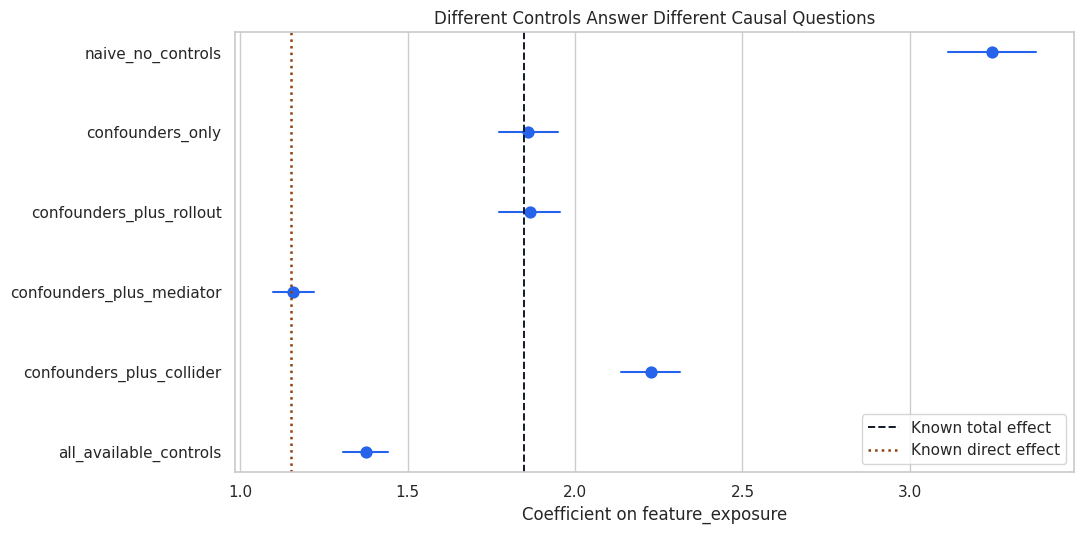

In [9]:
plot_manual = manual_adjustment_results.copy()
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.pointplot(
    data=plot_manual,
    x="estimate",
    y="specification",
    linestyle="none",
    color="#2563eb",
    ax=ax,
)
for i, row in plot_manual.reset_index(drop=True).iterrows():
    ax.plot([row["ci_95_lower"], row["ci_95_upper"]], [i, i], color="#2563eb", linewidth=1.5)
ax.axvline(truth["true_total_effect"], color="#111827", linestyle="--", linewidth=1.4, label="Known total effect")
ax.axvline(truth["direct_effect"], color="#92400e", linestyle=":", linewidth=1.8, label="Known direct effect")
ax.set_title("Different Controls Answer Different Causal Questions")
ax.set_xlabel("Coefficient on feature_exposure")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_adjustment_set_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The visual makes the warning concrete: using all available controls is not the same as estimating the total effect. The graph determines which controls are appropriate.


### Convert the Main Graph to DoWhy DOT Syntax

DoWhy can receive a graph as a DOT string. This function converts an edge list into a simple DOT graph string that we can reuse for several graph variants.


In [10]:
def edges_to_dot(edges):
    """
    Idea: Convert an edge table into DOT graph syntax for DoWhy or Graphviz-style display.
    
    Parameters
    ----------
    edges : object
        Collection of graph edges to draw, compare, or convert into a table.
    
    Returns
    -------
    str
        DOT graph string that can be passed to DoWhy or Graphviz-style renderers.
    """
    lines = ["digraph {"]
    for source, target in edges:
        lines.append(f"    {source} -> {target};")
    lines.append("}")
    return "\n".join(lines)
correct_total_graph = edges_to_dot(main_edges)
print(correct_total_graph)


digraph {
    user_engagement -> feature_exposure;
    user_engagement -> satisfaction_depth;
    user_engagement -> weekly_value;
    prior_activity -> feature_exposure;
    prior_activity -> satisfaction_depth;
    prior_activity -> weekly_value;
    account_age_weeks -> feature_exposure;
    account_age_weeks -> satisfaction_depth;
    account_age_weeks -> weekly_value;
    rollout_batch -> feature_exposure;
    feature_exposure -> satisfaction_depth;
    satisfaction_depth -> weekly_value;
    feature_exposure -> weekly_value;
    feature_exposure -> support_ticket;
    weekly_value -> support_ticket;
}


This DOT graph is the same design shown in the figure. The next cells will use it to create DoWhy models and compare it to flawed graph variants.


#### DoWhy with the Main Graph

The code below creates a DoWhy `CausalModel` using the main graph. We inspect common causes and instruments before estimating anything.

One practical note: helper methods such as `get_common_causes()` are useful diagnostics, but the graph and printed estimand remain the clearest statement of assumptions.


In [11]:
# Fit or evaluate the model objects used in the DoWhy With The Main Graph section.
model_columns = [
    "feature_exposure",
    "weekly_value",
    "satisfaction_depth",
    "user_engagement",
    "prior_activity",
    "account_age_weeks",
    "rollout_batch",
    "support_ticket",
]
dowhy_df = graph_df[model_columns].copy()
correct_model = CausalModel(
    data=dowhy_df,
    treatment="feature_exposure",
    outcome="weekly_value",
    graph=correct_total_graph,
)
correct_model_metadata = pd.DataFrame(
    [
        {"component": "common_causes_reported_by_DoWhy", "value": ", ".join(correct_model.get_common_causes())},
        {"component": "instruments_reported_by_DoWhy", "value": ", ".join(correct_model.get_instruments()) or "none detected"},
        {"component": "effect_modifiers_reported_by_DoWhy", "value": ", ".join(correct_model.get_effect_modifiers()) or "none detected"},
    ]
)
correct_model_metadata.to_csv(TABLE_DIR / "02_correct_graph_dowhy_metadata.csv", index=False)
correct_model_metadata


,component,value
0,common_causes_reported_by_DoWhy,"account_age_weeks, user_engagement, prior_activity, rollout_batch"
1,instruments_reported_by_DoWhy,rollout_batch
2,effect_modifiers_reported_by_DoWhy,none detected


DoWhy detects the graph structure and reports candidate common causes and instruments. The important causal design remains: block baseline backdoor paths while preserving the treatment-to-mediator-to-outcome path.


### Identify the Effect Under the Main Graph

Now DoWhy identifies the estimand under the main graph. The printed output is verbose because it exposes the assumptions needed for the effect estimate.


In [12]:
correct_estimand = correct_model.identify_effect(proceed_when_unidentifiable=True)
print(correct_estimand)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
──────────────────(E[weekly_value|account_age_weeks,user_engagement,prior_acti ↪
d[featureₑₓₚₒₛᵤᵣₑ]                                                             ↪

↪       
↪ vity])
↪       
Estimand assumption 1, Unconfoundedness: If U→{feature_exposure} and U→weekly_value then P(weekly_value|feature_exposure,account_age_weeks,user_engagement,prior_activity,U) = P(weekly_value|feature_exposure,account_age_weeks,user_engagement,prior_activity)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                   -1⎤
 ⎢       d                      ⎛       d                           ⎞  ⎥
E⎢────────────────(weeklyᵥₐₗᵤₑ)⋅⎜────────────────([featureₑₓₚₒₛᵤᵣₑ])⎟  ⎥
 ⎣d[rollout_batch]              ⎝d[rollout_batch]                   ⎠  ⎦
Estimand assum

For this total-effect question, the identified estimand relies on an adjustment strategy that blocks the baseline backdoor paths. It does not ask us to control for the mediator as a normal covariate.


### Estimate the Effect Under the Main Graph

Now we estimate the identified effect using DoWhy's linear-regression estimator. Since the data-generating process is simple and the graph is correct, the estimate should land near the known total effect.


In [13]:
correct_estimate = correct_model.estimate_effect(
    correct_estimand,
    method_name="backdoor.linear_regression",
)
print(correct_estimate)
print(f"DoWhy estimate under main graph: {float(correct_estimate.value):.4f}")
print(f"Known total effect: {truth['true_total_effect']:.4f}")
print(f"Known direct effect: {truth['direct_effect']:.4f}")


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
──────────────────(E[weekly_value|account_age_weeks,user_engagement,prior_acti ↪
d[featureₑₓₚₒₛᵤᵣₑ]                                                             ↪

↪       
↪ vity])
↪       
Estimand assumption 1, Unconfoundedness: If U→{feature_exposure} and U→weekly_value then P(weekly_value|feature_exposure,account_age_weeks,user_engagement,prior_activity,U) = P(weekly_value|feature_exposure,account_age_weeks,user_engagement,prior_activity)

## Realized estimand
b: weekly_value~feature_exposure+account_age_weeks+user_engagement+prior_activity
Target units: ate

## Estimate
Mean value: 1.860164020591021

DoWhy estimate under main graph: 1.8602
Known total effect: 1.8475
Known direct effect: 1.1500


The estimate should be close to the known total effect, not the direct effect. That is exactly what we want because the graph preserved the mediated pathway through `satisfaction_depth`.




#### Compare Correct and Flawed Graphs

To see why graph assumptions matter, we will compare four graph specifications:

- The main graph.
- A graph that omits `user_engagement` as a confounder.
- A graph that incorrectly treats the mediator as a pre-treatment common cause.
- A graph that incorrectly treats the collider as a pre-treatment common cause.

Only the first graph matches the data-generating process.


In [14]:
missing_user_engagement_edges = [edge for edge in main_edges if "user_engagement" not in edge]
mediator_as_confounder_edges = [
    ("user_engagement", "feature_exposure"),
    ("user_engagement", "weekly_value"),
    ("prior_activity", "feature_exposure"),
    ("prior_activity", "weekly_value"),
    ("account_age_weeks", "feature_exposure"),
    ("account_age_weeks", "weekly_value"),
    ("satisfaction_depth", "feature_exposure"),
    ("satisfaction_depth", "weekly_value"),
    ("rollout_batch", "feature_exposure"),
    ("feature_exposure", "weekly_value"),
    ("feature_exposure", "support_ticket"),
    ("weekly_value", "support_ticket"),
]
collider_as_confounder_edges = [
    ("user_engagement", "feature_exposure"),
    ("user_engagement", "satisfaction_depth"),
    ("user_engagement", "weekly_value"),
    ("prior_activity", "feature_exposure"),
    ("prior_activity", "satisfaction_depth"),
    ("prior_activity", "weekly_value"),
    ("account_age_weeks", "feature_exposure"),
    ("account_age_weeks", "satisfaction_depth"),
    ("account_age_weeks", "weekly_value"),
    ("rollout_batch", "feature_exposure"),
    ("support_ticket", "feature_exposure"),
    ("support_ticket", "weekly_value"),
    ("feature_exposure", "satisfaction_depth"),
    ("satisfaction_depth", "weekly_value"),
    ("feature_exposure", "weekly_value"),
]
graph_variants = {
    "main_graph_total_effect": main_edges,
    "missing_user_engagement_confounder": missing_user_engagement_edges,
    "mediator_treated_as_confounder": mediator_as_confounder_edges,
    "collider_treated_as_confounder": collider_as_confounder_edges,
}
variant_checks = []
for name, edges in graph_variants.items():
    variant_graph = nx.DiGraph(edges)
    variant_checks.append(
        {
            "graph_variant": name,
            "node_count": variant_graph.number_of_nodes(),
            "edge_count": variant_graph.number_of_edges(),
            "is_dag": nx.is_directed_acyclic_graph(variant_graph),
        }
    )
variant_check_df = pd.DataFrame(variant_checks)
variant_check_df.to_csv(TABLE_DIR / "02_graph_variant_checks.csv", index=False)
variant_check_df


,graph_variant,node_count,edge_count,is_dag
0,main_graph_total_effect,8,15,True
1,missing_user_engagement_confounder,7,12,True
2,mediator_treated_as_confounder,8,12,True
3,collider_treated_as_confounder,8,15,True


All variants are DAGs, but being acyclic is not enough. A DAG can be internally valid as a graph and still be causally wrong for the system being studied.




#### Estimate Under Each Graph Variant

The code below runs the same DoWhy workflow under each graph variant. The data and estimator stay fixed; only the graph assumptions change.


In [15]:
# Fit or evaluate the model objects used in the Estimate Under Each Graph Variant section.
variant_rows = []
for graph_name, edges in graph_variants.items():
    dot_graph = edges_to_dot(edges)
    variant_model = CausalModel(
        data=dowhy_df,
        treatment="feature_exposure",
        outcome="weekly_value",
        graph=dot_graph,
    )
    variant_estimand = variant_model.identify_effect(proceed_when_unidentifiable=True)
    variant_estimate = variant_model.estimate_effect(
        variant_estimand,
        method_name="backdoor.linear_regression",
    )
    estimate_value = float(variant_estimate.value)
    variant_rows.append(
        {
            "graph_variant": graph_name,
            "reported_common_causes": ", ".join(variant_model.get_common_causes()),
            "reported_instruments": ", ".join(variant_model.get_instruments()) or "none detected",
            "estimate": estimate_value,
            "distance_from_true_total": abs(estimate_value - truth["true_total_effect"]),
            "distance_from_true_direct": abs(estimate_value - truth["direct_effect"]),
        }
    )
variant_results = pd.DataFrame(variant_rows)
variant_results.to_csv(TABLE_DIR / "02_dowhy_graph_variant_results.csv", index=False)
variant_results


,graph_variant,reported_common_causes,reported_instruments,estimate,distance_from_true_total,distance_from_true_direct
0,main_graph_total_effect,"account_age_weeks, user_engagement, prior_activity, rollout_batch",rollout_batch,1.860164,0.012664,0.710164
1,missing_user_engagement_confounder,"account_age_weeks, prior_activity, rollout_batch",rollout_batch,2.951717,1.104217,1.801717
2,mediator_treated_as_confounder,"account_age_weeks, user_engagement, prior_activity, satisfaction_depth",rollout_batch,1.158695,0.688805,0.008695
3,collider_treated_as_confounder,"rollout_batch, support_ticket, user_engagement, prior_activity, account_age_weeks",rollout_batch,2.225349,0.377849,1.075349


The graph variant changes the adjustment logic and therefore the estimate. The missing-confounder graph leaves a backdoor path open. The mediator-as-confounder graph blocks part of the total effect. The collider-as-confounder graph conditions on a post-treatment collider.


#### Plot the Graph Variant Results

The plot below puts the graph variants next to the known total and direct effects. This is the central lesson of the lesson: graph assumptions change the meaning of the estimate.


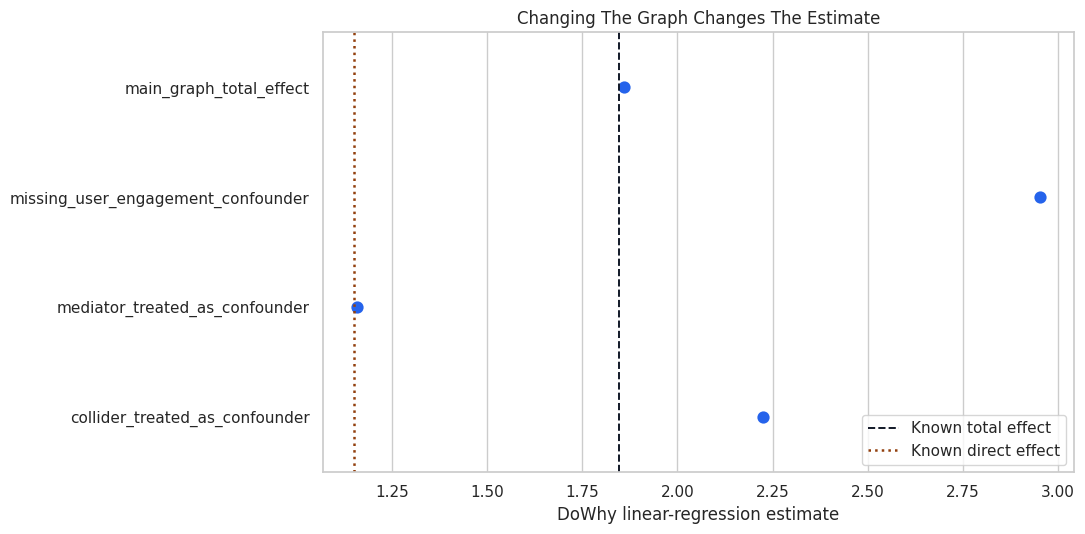

In [16]:
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.pointplot(
    data=variant_results,
    x="estimate",
    y="graph_variant",
    linestyle="none",
    color="#2563eb",
    ax=ax,
)
ax.axvline(truth["true_total_effect"], color="#111827", linestyle="--", linewidth=1.4, label="Known total effect")
ax.axvline(truth["direct_effect"], color="#92400e", linestyle=":", linewidth=1.8, label="Known direct effect")
ax.set_title("Changing The Graph Changes The Estimate")
ax.set_xlabel("DoWhy linear-regression estimate")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_dowhy_graph_variant_results.png", dpi=160, bbox_inches="tight")
plt.show()


The main graph is closest to the total-effect benchmark. The flawed graphs may still produce precise-looking numbers, but those numbers answer a different or biased question.


#### Draw the Flawed Graphs Side by Side

The next plot shows simplified versions of the three flawed graph ideas. This is useful because graph mistakes are often easier to catch visually than in a formula.


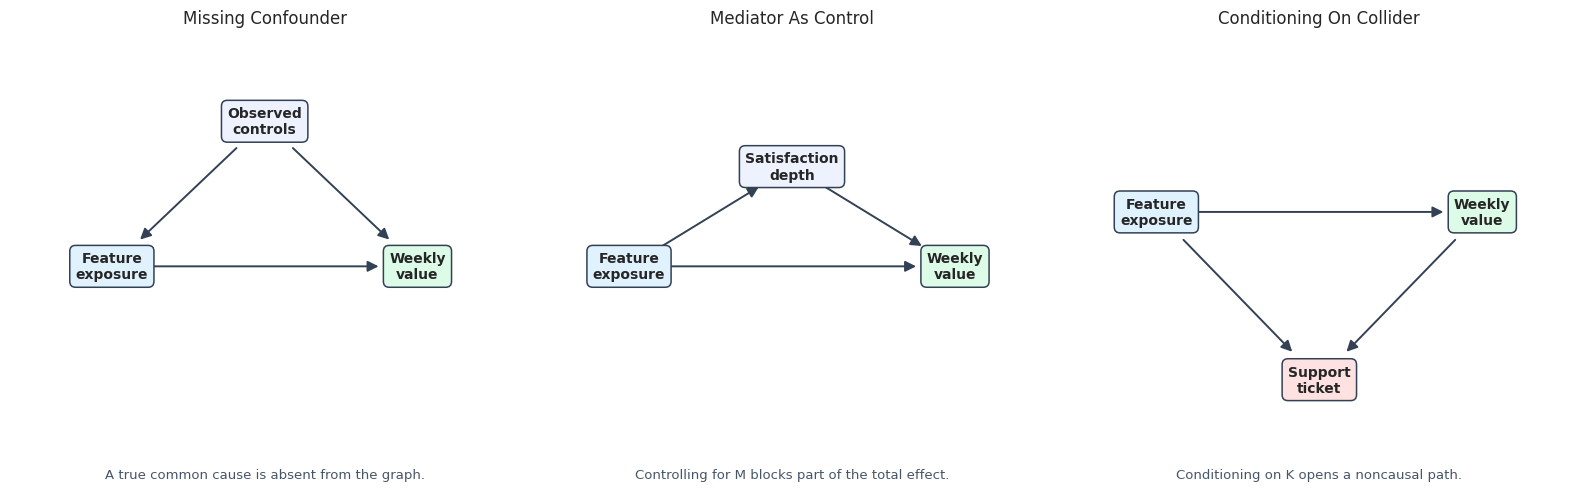

In [17]:
# Build and label the diagnostic visualization for the Draw The Flawed Graphs Side By Side section.
flaw_panels = [
    {
        "title": "Missing Confounder",
        "nodes": {
            "A": (0.20, 0.50),
            "Y": (0.80, 0.50),
            "C": (0.50, 0.82),
        },
        "labels": {"A": "Feature\nexposure", "Y": "Weekly\nvalue", "C": "Observed\ncontrols"},
        "edges": [("C", "A"), ("C", "Y"), ("A", "Y")],
        "note": "A true common cause is absent from the graph.",
    },
    {
        "title": "Mediator As Control",
        "nodes": {
            "A": (0.18, 0.50),
            "M": (0.50, 0.72),
            "Y": (0.82, 0.50),
        },
        "labels": {"A": "Feature\nexposure", "M": "Satisfaction\ndepth", "Y": "Weekly\nvalue"},
        "edges": [("A", "M"), ("M", "Y"), ("A", "Y")],
        "note": "Controlling for M blocks part of the total effect.",
    },
    {
        "title": "Conditioning On Collider",
        "nodes": {
            "A": (0.18, 0.62),
            "Y": (0.82, 0.62),
            "K": (0.50, 0.25),
        },
        "labels": {"A": "Feature\nexposure", "Y": "Weekly\nvalue", "K": "Support\nticket"},
        "edges": [("A", "K"), ("Y", "K"), ("A", "Y")],
        "note": "Conditioning on K opens a noncausal path.",
    },
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
for ax, panel in zip(axes, flaw_panels):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_axis_off()
    for source, target in panel["edges"]:
        ax.annotate(
            "",
            xy=panel["nodes"][target],
            xytext=panel["nodes"][source],
            arrowprops=dict(
                arrowstyle="-|>",
                color="#334155",
                linewidth=1.4,
                mutation_scale=16,
                shrinkA=28,
                shrinkB=28,
            ),
            zorder=1,
        )
    for node, (x, y) in panel["nodes"].items():
        color = "#e0f2fe" if node == "A" else "#dcfce7" if node == "Y" else "#fee2e2" if node == "K" else "#eef2ff"
        ax.text(
            x,
            y,
            panel["labels"][node],
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.42", facecolor=color, edgecolor="#334155", linewidth=1.1),
            zorder=2,
        )
    ax.set_title(panel["title"], pad=12)
    ax.text(0.5, 0.04, panel["note"], ha="center", va="center", fontsize=9.5, color="#475569")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_common_graph_mistakes.png", dpi=160, bbox_inches="tight")
plt.show()


These mistakes are common because all three flawed graphs can feel plausible if we think only in predictive terms. Causal graphs force us to ask whether a variable is pre-treatment, post-treatment, or a common effect.





## Reporting and Takeaways

### Assumption Documentation Template

A causal graph should be accompanied by written assumptions. The table below is a template for documenting the main arrows and the consequence if each assumption is wrong.


| assumption | graph_arrows | why_it_matters | risk_if_wrong |
| --- | --- | --- | --- |
| Baseline engagement affects exposure and future value. | user_engagement -> feature_exposure; user_engagement -> weekly_value | Engagement is a confounder and should be adjusted for. | If omitted, the exposure effect can be overstated. |
| Prior activity affects exposure and future value. | prior_activity -> feature_exposure; prior_activity -> weekly_value | Prior behavior is a pre-treatment common cause. | Treatment and control users are not comparable. |
| Exposure changes satisfaction depth, which changes future value. | feature_exposure -> satisfaction_depth -> weekly_value | This path is part of the total effect. | Adjusting for satisfaction changes the estimand from total to direct-like. |
| Rollout shifts exposure without directly changing future value. | rollout_batch -> feature_exposure | Rollout is instrument-like rather than a confounder. | A direct rollout effect would need to be represented in the graph. |
| Support ticket is a common effect of exposure and future value. | feature_exposure -> support_ticket <- weekly_value | Support ticket is a collider and should not be adjusted for in total-effect estimation. | Conditioning on support can open a noncausal path. |


This register is the part of the analysis a reviewer should challenge. A polished causal analysis should make those challenges easy by stating assumptions plainly.


### Final Graph Checklist

This final checklist summarizes the graph workflow students should use before estimating effects with DoWhy.


| step | student_prompt |
| --- | --- |
| State the causal question | Am I estimating a total effect, direct effect, mediated effect, or something else? |
| Mark variable timing | Which variables are measured before treatment, at treatment, after treatment, and after outcome? |
| Classify variable roles | Which variables are confounders, mediators, colliders, instruments, or outcomes? |
| Draw the DAG | Do all arrows follow the assumed time ordering and domain logic? |
| Check for cycles | Is this a directed acyclic graph? |
| List paths | Which paths should be blocked and which causal paths should stay open? |
| Choose adjustment variables | Am I avoiding post-treatment mediators and colliders for a total-effect question? |
| Use DoWhy to identify | What estimand and assumptions does DoWhy print before estimation? |
| Estimate and compare | Does the estimate change dramatically under plausible alternative graphs? |
| Document limitations | Which arrows are strongest, weakest, or least testable? |


The checklist is deliberately slow. In causal inference, speed usually comes after the graph is clear, not before.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


### Student Exercises

After running the lesson, try these modifications:

1. Remove the mediator path `feature_exposure -> satisfaction_depth -> weekly_value` and rerun the DoWhy estimate.
2. Add a direct arrow `rollout_batch -> weekly_value` and decide whether rollout is still instrument-like.
3. Change the support-ticket equation so the collider is rarer or more common and observe the collider-adjustment estimate.
4. Create a graph with a cycle and check what NetworkX says.
5. Write your own assumption register for a real dataset you care about.


## Closing Notes

This section shows that graph assumptions are not cosmetic. The same data and estimator can produce different answers when the graph changes. The sequence next focuses more narrowly on backdoor adjustment and confounding, building on the graph vocabulary introduced here.
